# Simulating Option Delta under the BSM Framework

## Objective

This notebook provides a sample demonstration of how the behaviour of an option's Delta can be simulated under the BSM framework.

Similar to the graphs discussed in class, we examine how call and put Delta change with:

- Underlying asset price
- Option moneyness
- Time to maturity
- Volatility

This assumes a fixed strike price, risk-free interest rate and dividend yield. A range of values is then simulated for the underlying price, volatility and time to maturity.

This notebook provides only one possible approach. The same relationships can be studied using different parameter grids, functions, data structures, visualziations or numerical methods. You can absolutely modify the code or use an alternative valid approach, provided that the calculations are consistent with the BSM framework.

This exercise focuses only on Delta as an illustrative example. A similar procedure can be used to study the other greeks.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from itertools import product

## 1. Parameter Setup and Simulation Grid

We begin by specifying the fixed parameters of the Black–Scholes–Merton model:

- Strike price: $K = 100$
- Risk-free interest rate: $r = 0.05$
- Dividend yield: $q = 0$

We allow the following parameters to vary:

- Stock price ($S$): 50 to 150, in increments of 1
- Volatility ($\sigma$): 5% to 60%, in increments of 1 percentage point
- Time to maturity ($T$): approximately one week to two years

The `product()` function creates every possible combination of stock price, volatility, and time to maturity. Each row of `df` therefore represents a different simulated option scenario.

In [21]:
K = 100
r = 0.05
q = 0

S_values = np.arange(50, 151, 1)
sigma_values = np.arange(0.05, 0.61, 0.01)
T_values = np.r_[1/52, np.arange(0.05, 2.01, 0.05)]

df = pd.DataFrame(
    product(S_values, sigma_values, T_values),
    columns=["S", "sigma", "T"]
)

df.shape

(231896, 3)

## Calculation of $d_1$ and $d_2$

$$
d_1 = \frac{\ln(S/K) + \left(r-q+\frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1-\sigma\sqrt{T}
$$

In [22]:
df["d1"] = (np.log(df["S"] / K) + (r - q + df["sigma"]**2 / 2) * df["T"]) / (df["sigma"] * np.sqrt(df["T"]))

df["d2"] = df["d1"] - df["sigma"] * np.sqrt(df["T"])

In [23]:
df["N_d1"] = norm.cdf(df["d1"])
df["N_d2"] = norm.cdf(df["d2"])

df.head()

,S,sigma,T,d1,d2,N_d1,N_d2
0,50,0.05,0.019231,-99.824966,-99.831900,0.000000e+00,0.000000e+00
1,50,0.05,0.050000,-61.767772,-61.778952,0.000000e+00,0.000000e+00
2,50,0.05,0.100000,-43.514343,-43.530155,0.000000e+00,0.000000e+00
3,50,0.05,0.150000,-35.396986,-35.416351,9.499514e-275,4.782901e-275
4,50,0.05,0.200000,-30.540090,-30.562451,3.827978e-205,1.931814e-205


## Calculation of Delta

$$
\Delta_{\text{call}} = e^{-qT}N(d_1)
$$

$$
\Delta_{\text{put}} = e^{-qT}\left[N(d_1)-1\right]
$$

In [24]:
df["call_delta"] = np.exp(-q * df["T"]) * df["N_d1"]
df["put_delta"] = np.exp(-q * df["T"]) * (df["N_d1"] - 1)

df["moneyness"] = df["S"] / K

df.head()

,S,sigma,T,d1,d2,N_d1,N_d2,call_delta,put_delta,moneyness
0,50,0.05,0.019231,-99.824966,-99.831900,0.000000e+00,0.000000e+00,0.000000e+00,-1.0,0.5
1,50,0.05,0.050000,-61.767772,-61.778952,0.000000e+00,0.000000e+00,0.000000e+00,-1.0,0.5
2,50,0.05,0.100000,-43.514343,-43.530155,0.000000e+00,0.000000e+00,0.000000e+00,-1.0,0.5
3,50,0.05,0.150000,-35.396986,-35.416351,9.499514e-275,4.782901e-275,9.499514e-275,-1.0,0.5
4,50,0.05,0.200000,-30.540090,-30.562451,3.827978e-205,1.931814e-205,3.827978e-205,-1.0,0.5


## Delta and Moneyness

This graph examines how call and put Delta change with option moneyness:

$$
\text{Moneyness}=\frac{S}{K}
$$

For this comparison:

- The stock price $S$, and therefore $S/K$, is allowed to change.
- Volatility is held constant at $\sigma=20\%$.
- Time to maturity is held constant at $T=1$ year.
- The strike price remains fixed at $K=100$.
- The risk-free rate and dividend yield remain fixed at $r=5\%$ and $q=0$.

The code first filters the complete simulation dataset to retain only observations with $\sigma=20\%$ and $T=1$. It then plots call and put Delta against $S/K$.

The vertical line at $S/K=1$ identifies the at-the-money point:

- $S/K<1$: the call is out of the money and the put is in the money.
- $S/K=1$: the options are at the money.
- $S/K>1$: the call is in the money and the put is out of the money.

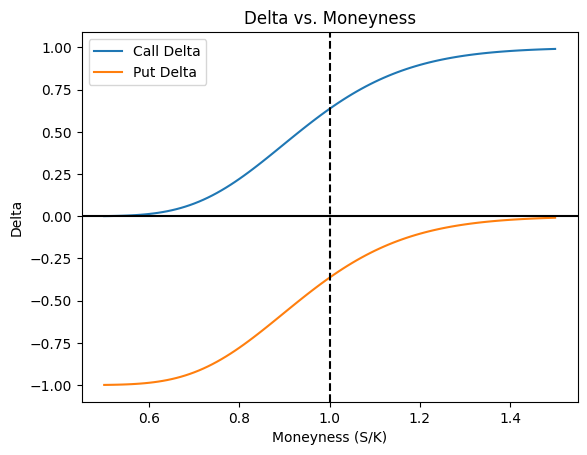

In [27]:
x = df[
    np.isclose(df["sigma"], 0.20)
    & np.isclose(df["T"], 1)
]

plt.plot(x["moneyness"], x["call_delta"], label="Call Delta")
plt.plot(x["moneyness"], x["put_delta"], label="Put Delta")

plt.axhline(0, color="black")
plt.axvline(1, color="black", linestyle="--")

plt.xlabel("Moneyness (S/K)")
plt.ylabel("Delta")
plt.title("Delta vs. Moneyness")
plt.legend()
plt.show()

### Delta and Moneyness at Different Volatility Levels

This graph plots call and put Delta against moneyness for three volatility levels: 10%, 20%, and 40%.

Time to maturity is held constant at one year, while moneyness changes through variations in the stock price. The strike price, risk-free rate, and dividend yield remain fixed.

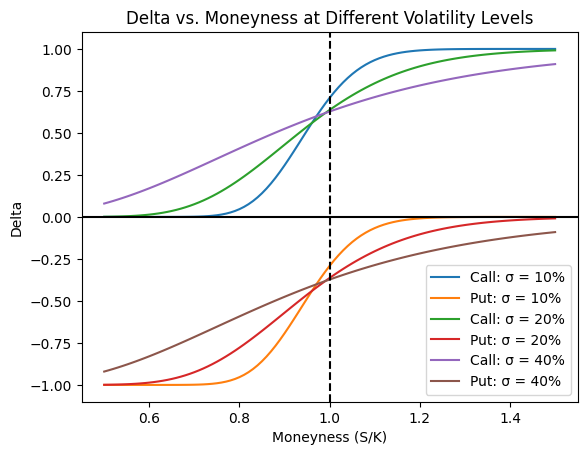

In [25]:
for sigma in [0.10, 0.20, 0.40]:
    x = df[np.isclose(df["T"], 1) & np.isclose(df["sigma"], sigma)]

    plt.plot(x["moneyness"], x["call_delta"],
             label=f"Call: σ = {sigma:.0%}")

    plt.plot(x["moneyness"], x["put_delta"],
             label=f"Put: σ = {sigma:.0%}")

plt.axhline(0, color="black")
plt.axvline(1, color="black", linestyle="--")

plt.xlabel("Moneyness (S/K)")
plt.ylabel("Delta")
plt.title("Delta vs. Moneyness at Different Volatility Levels")
plt.legend()
plt.show()

### Delta and Moneyness at Different Maturities

This graph plots call and put Delta against moneyness for three times to maturity: 0.25, 1, and 2 years.

Volatility is held constant at 20%, while moneyness changes through variations in the stock price. The strike price, risk-free rate, and dividend yield remain fixed.

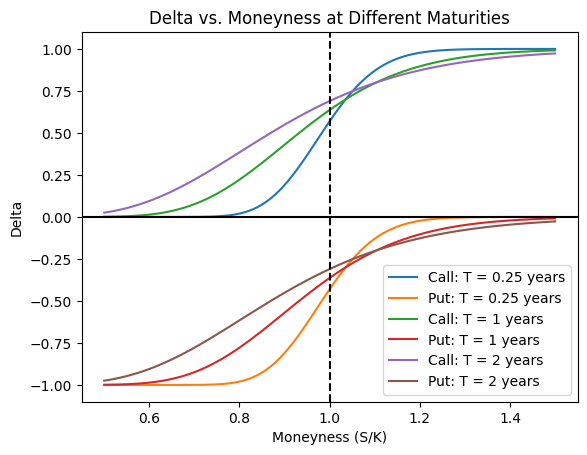

In [26]:
for T in [0.25, 1, 2]:
    x = df[np.isclose(df["sigma"], 0.20) & np.isclose(df["T"], T)]

    plt.plot(x["moneyness"], x["call_delta"],
             label=f"Call: T = {T} years")

    plt.plot(x["moneyness"], x["put_delta"],
             label=f"Put: T = {T} years")

plt.axhline(0, color="black")
plt.axvline(1, color="black", linestyle="--")

plt.xlabel("Moneyness (S/K)")
plt.ylabel("Delta")
plt.title("Delta vs. Moneyness at Different Maturities")
plt.legend()
plt.show()

### Delta and Volatility at Different Moneyness Levels

This graph plots call and put Delta against volatility for three moneyness levels: $S/K=0.8$, $1.0$, and $1.2$.

Time to maturity is held constant at one year. Moneyness is varied by changing the stock price while keeping the strike price fixed at $K=100$. The risk-free rate and dividend yield also remain fixed.

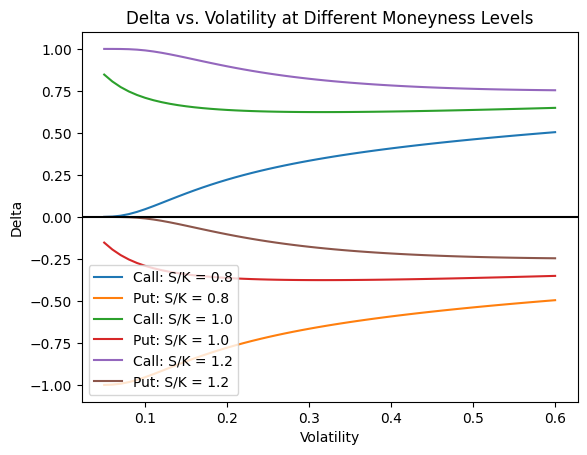

In [31]:
for S in [80, 100, 120]:
    x = df[(df["S"] == S) & np.isclose(df["T"], 1)]

    plt.plot(x["sigma"], x["call_delta"],
             label=f"Call: S/K = {S/K:.1f}")

    plt.plot(x["sigma"], x["put_delta"],
             label=f"Put: S/K = {S/K:.1f}")

plt.axhline(0, color="black")
plt.xlabel("Volatility")
plt.ylabel("Delta")
plt.title("Delta vs. Volatility at Different Moneyness Levels")
plt.legend()
plt.show()

### Delta and Volatility Across Maturity and Moneyness

The figure divides the analysis into three moneyness levels: $S/K=0.8$, $1.0$, and $1.2$.

Within each graph, call and put Delta are plotted against volatility for maturities of 0.25, 1, and 2 years. The strike price, risk-free rate, and dividend yield remain fixed. Solid lines represent calls, while dashed lines represent puts.

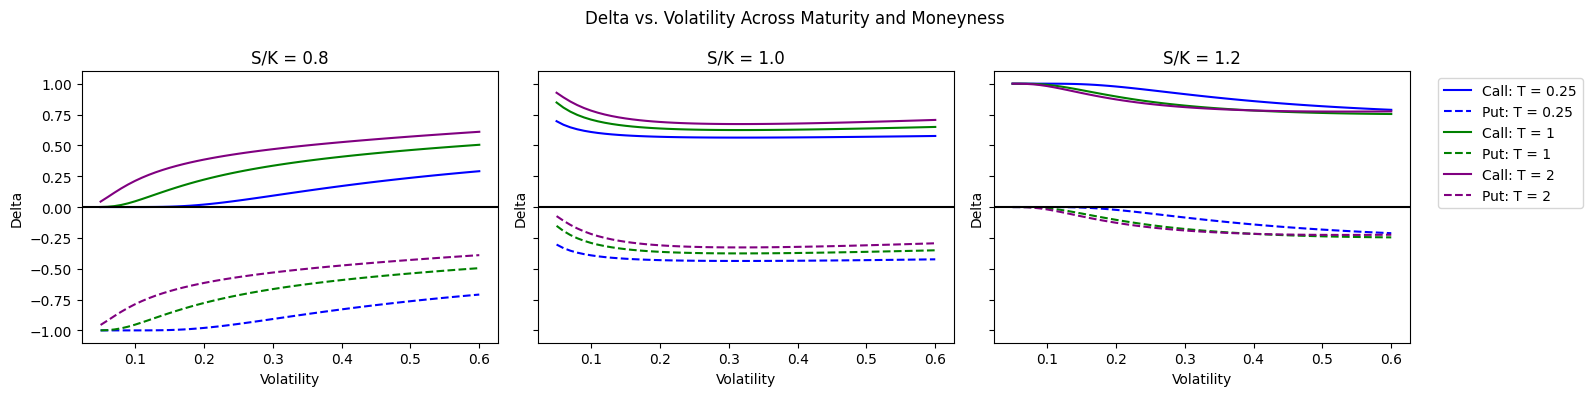

In [33]:
colors = ["blue", "green", "purple"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, S in zip(axes, [80, 100, 120]):
    for T, color in zip([0.25, 1, 2], colors):
        x = df[(df["S"] == S) & np.isclose(df["T"], T)]

        ax.plot(x["sigma"], x["call_delta"],
                color=color, label=f"Call: T = {T}")

        ax.plot(x["sigma"], x["put_delta"],
                color=color, linestyle="--", label=f"Put: T = {T}")

    ax.axhline(0, color="black")
    ax.set_title(f"S/K = {S/K:.1f}")
    ax.set_xlabel("Volatility")
    ax.set_ylabel("Delta")

axes[-1].legend(bbox_to_anchor=(1.05, 1))
fig.suptitle("Delta vs. Volatility Across Maturity and Moneyness")
plt.tight_layout()
plt.show()

## Put-Call Parity Check for Delta

Put-call parity implies that the difference between call and put Delta is:

$$
\Delta_{\text{call}}-\Delta_{\text{put}}=e^{-qT}
$$

Since the dividend yield is assumed to be zero, $q=0$:

$$
e^{-qT}=e^0=1
$$

Therefore:

$$
\Delta_{\text{call}}-\Delta_{\text{put}}=1
$$

The code calculates the parity error for every simulated parameter combination. A maximum error of zero confirms that Delta parity holds throughout the simulation.

In [35]:
df["parity_error"] = (
    df["call_delta"] - df["put_delta"] - np.exp(-q * df["T"])
)

print("Maximum parity error:", df["parity_error"].abs().max())

Maximum parity error: 0.0
